# Smoothing Techniques

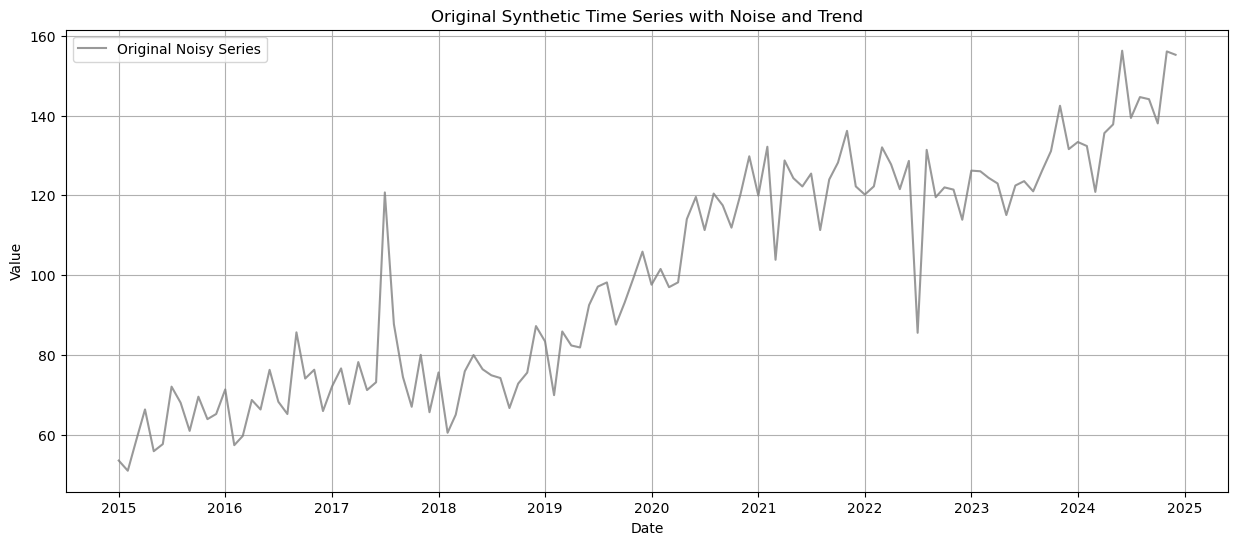

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing
from statsmodels.nonparametric.smoothers_lowess import lowess # For LOESS/LOWESS

# 1. Generate a Synthetic Time Series with Noise and Trend
np.random.seed(42)
n_points = 120 # 10 years of monthly data
index = pd.date_range(start='2015-01-01', periods=n_points, freq='MS')

# Base trend
base_trend = np.linspace(50, 150, n_points) + 10 * np.sin(np.linspace(0, 4*np.pi, n_points))

# Add some irregular fluctuations/noise
noise = np.random.normal(0, 7, n_points) # Standard deviation of 7
# Add a few spikes/outliers
noise[30] += 50
noise[90] -= 40

original_series = pd.Series(base_trend + noise, index=index)

# Plot the original noisy series
plt.figure(figsize=(15, 6))
plt.plot(original_series, label='Original Noisy Series', color='grey', alpha=0.8)
plt.title('Original Synthetic Time Series with Noise and Trend')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.show()

In [2]:
# --- 2. Smoothing Techniques ---

# a) Simple Moving Average (SMA)
# The window size is crucial. Larger window = smoother, but more lag and initial NaNs.
window_size_sma = 6 # e.g., 6-month moving average
sma_series = original_series.rolling(window=window_size_sma).mean()

# b) Exponential Moving Average (EMA)
# `span` is roughly equivalent to a window in terms of effective average.
# `adjust=False` provides a simpler formula often used in finance.
# `com` (center of mass) or `halflife` can also be used.
ema_series_span_12 = original_series.ewm(span=12, adjust=False).mean()
ema_series_span_4 = original_series.ewm(span=4, adjust=False).mean() # Less smooth, more responsive

# c) Simple Exponential Smoothing (SES) - from statsmodels
# 'smoothing_level' (alpha) is the smoothing parameter (0 to 1). Higher alpha = more weight to recent data.
# For SES, it's typically used for data without trend or seasonality, but it can be applied to extract a smoothed level.
ses_model = SimpleExpSmoothing(original_series, initialization_method="estimated").fit()
ses_smoothed = ses_model.fittedvalues

# d) Holt's Linear Trend (Double Exponential Smoothing) - from statsmodels
# For data with a trend but no seasonality.
# 'smoothing_level' (alpha) and 'smoothing_trend' (beta) are the parameters.
holt_model = Holt(original_series, initialization_method="estimated").fit()
holt_smoothed = holt_model.fittedvalues

# e) LOESS / LOWESS
# `frac` controls the fraction of data used in each local regression.
# Smaller `frac` means less smoothing, larger `frac` means more smoothing.
# It returns an array, where the smoothed values are in the second column.
lowess_smoothed = lowess(original_series.values, np.arange(len(original_series)), frac=0.15)[:, 1] # frac=0.15 for 15% of data
lowess_smoothed_series = pd.Series(lowess_smoothed, index=original_series.index)

# f) Gaussian Smoothing
# `sigma` is the standard deviation of the Gaussian kernel. Larger sigma = more smoothing.
gaussian_smoothed = gaussian_filter1d(original_series.values, sigma=5) # Sigma of 5 for moderate smoothing
gaussian_smoothed_series = pd.Series(gaussian_smoothed, index=original_series.index)


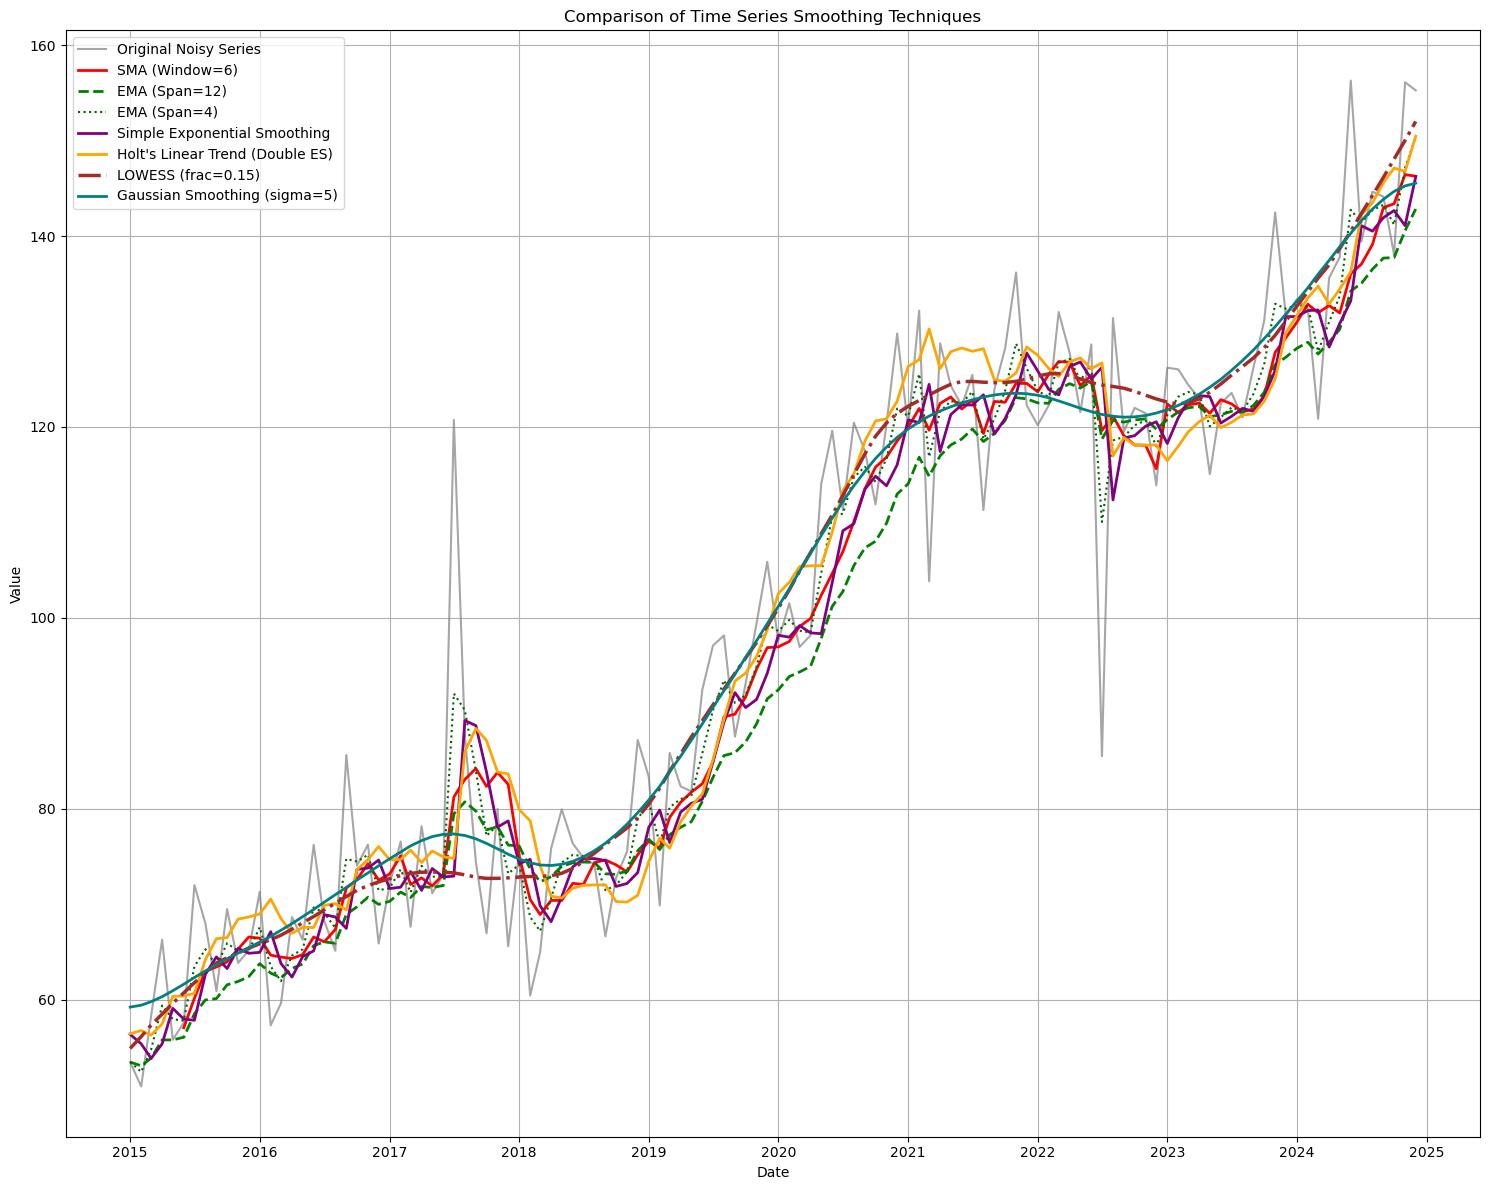

In [3]:
# --- 3. Plotting the Smoothed Series ---
plt.figure(figsize=(15, 12))

# Plot Original
plt.plot(original_series, label='Original Noisy Series', color='grey', alpha=0.7)

# Plot SMAs
plt.plot(sma_series, label=f'SMA (Window={window_size_sma})', color='red', linewidth=2)

# Plot EMAs
plt.plot(ema_series_span_12, label=f'EMA (Span=12)', color='green', linewidth=2, linestyle='--')
plt.plot(ema_series_span_4, label=f'EMA (Span=4)', color='darkgreen', linewidth=1.5, linestyle=':')

# Plot SES
plt.plot(ses_smoothed, label='Simple Exponential Smoothing', color='purple', linewidth=2)

# Plot Holt's (Double ES)
plt.plot(holt_smoothed, label='Holt\'s Linear Trend (Double ES)', color='orange', linewidth=2)

# Plot LOESS
plt.plot(lowess_smoothed_series, label='LOWESS (frac=0.15)', color='brown', linewidth=2.5, linestyle='-.')

# Plot Gaussian Smoothing
plt.plot(gaussian_smoothed_series, label='Gaussian Smoothing (sigma=5)', color='teal', linewidth=2)


plt.title('Comparison of Time Series Smoothing Techniques')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


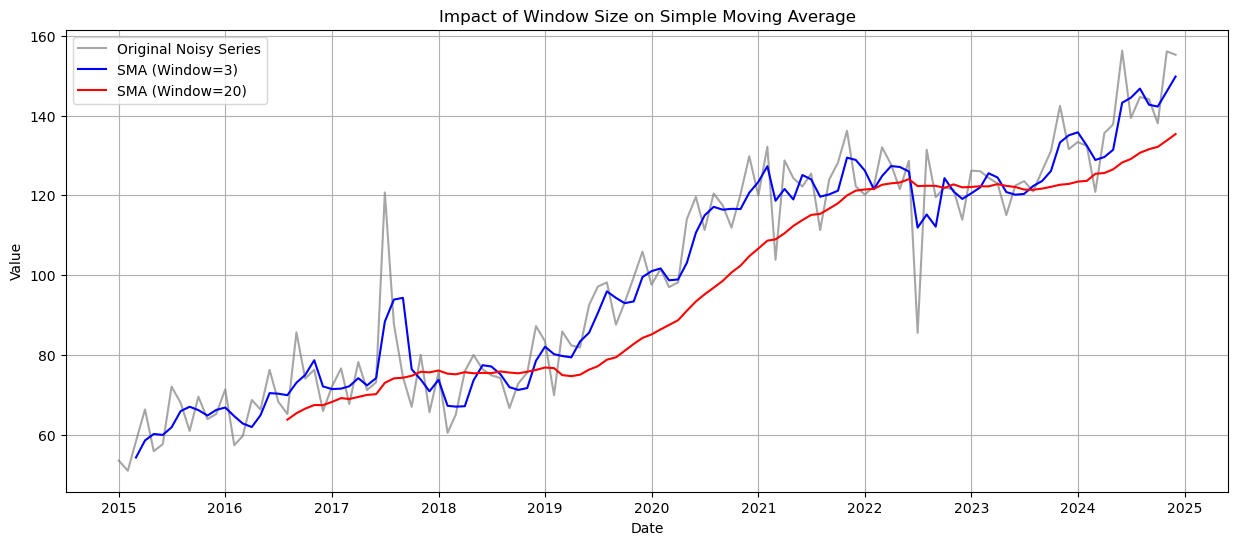

In [4]:
# --- Example of How smoothing parameters impact ---
plt.figure(figsize=(15, 6))
plt.plot(original_series, label='Original Noisy Series', color='grey', alpha=0.7)
plt.plot(original_series.rolling(window=3).mean(), label='SMA (Window=3)', color='blue')
plt.plot(original_series.rolling(window=20).mean(), label='SMA (Window=20)', color='red')
plt.title('Impact of Window Size on Simple Moving Average')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.show()